In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub torch einops

# UNET

**Paper:** [arXiv:1505.04597](https://arxiv.org/abs/1505.04597) — *U-Net: Convolutional Networks for Biomedical Image Segmentation* (Ronneberger et al., 2015).  
**Weights source:** [mateuszbuda/brain-segmentation-pytorch](https://github.com/mateuszbuda/brain-segmentation-pytorch)

This notebook walks through a **from-scratch JAX implementation** of U-Net applied to brain MRI segmentation.

---

### Paper Overview

U-Net's central contribution is the **skip connection** — rather than simply encoding then decoding, the decoder receives direct copies of encoder feature maps at each resolution level. This preserves spatial detail that would otherwise be lost during downsampling.

| Innovation | What it solves |
|---|---|
| **Skip connections** | Fuses low-level spatial detail with high-level semantics in the decoder |
| **Symmetric encoder-decoder** | Mirror structure ensures feature maps align at each resolution level |
| **Transposed convolution** | Learnable upsampling recovers spatial resolution |
| **Double conv block** | Two 3×3 convs per level give more representational power without large compute cost |

### Architecture at a Glance

```
Input (1, 3, 256, 256)
  ↓  Encoder L1: double_conv  →  (1,  32, 256, 256)  ──skip──┐
  ↓  maxpool 2×2              →  (1,  32, 128, 128)          │
  ↓  Encoder L2: double_conv  →  (1,  64, 128, 128)  ──skip──┤
  ↓  maxpool 2×2              →  (1,  64,  64,  64)          │
  ↓  Encoder L3: double_conv  →  (1, 128,  64,  64)  ──skip──┤
  ↓  maxpool 2×2              →  (1, 128,  32,  32)          │
  ↓  Encoder L4: double_conv  →  (1, 256,  32,  32)  ──skip──┤
  ↓  maxpool 2×2              →  (1, 256,  16,  16)          │
  ↓  Bottleneck: double_conv  →  (1, 512,  16,  16)          │
  ↑  upconv + concat skip     →  (1, 512,  32,  32)  ←───────┘
  ↑  Decoder L4: double_conv  →  (1, 256,  32,  32)  ←skip
  ↑  upconv + concat skip     →  (1, 256,  64,  64)
  ↑  Decoder L3: double_conv  →  (1, 128,  64,  64)  ←skip
  ↑  ... (mirror of encoder)
  ↑  Decoder L1: double_conv  →  (1,  32, 256, 256)
  ↓  1×1 conv + sigmoid       →  (1,   1, 256, 256)  binary mask
```

### Imports

In [1]:
from dataclasses import dataclass
from typing import Optional
import jax.numpy as jnp
import jax
import jax.nn as jnn
import numpy as np
from PIL import Image
from safetensors.torch import load_file
import json
import torch
from einops import rearrange, repeat, einsum

### Load & Convert Weights

Weights come from a pretrained PyTorch checkpoint. JAX uses a different axis convention for convolution kernels, so each weight is transposed on load:

| Layer type | PyTorch shape | JAX shape |
|---|---|---|
| `Conv2d` | `(C_out, C_in, kH, kW)` | `(kH, kW, C_in, C_out)` |
| `ConvTranspose2d` | `(C_in, C_out, kH, kW)` | `(kH, kW, C_out, C_in)` |
| `Linear` | `(C_out, C_in)` | `(C_in, C_out)` |

In [ ]:
WEIGHTS_PATH = "../../.models/unet/unet.pt"
MODEL_PATH = "../../.models/unet"

import torch
state_dict = torch.load(WEIGHTS_PATH, map_location='cpu')

def convert_weight(
    key: str,
    tensor
) -> jnp.ndarray:
    w = tensor.numpy()
    if 'conv' in key and 'weight' in key and w.ndim == 4:
        w = np.transpose(w, (2, 3, 1, 0))
    elif 'upconv' in key and 'weight' in key and w.ndim == 4:
        w = np.transpose(w, (2, 3, 1, 0))
    elif 'weight' in key and w.ndim == 2:
        w = w.T
    return jnp.array(w)

jax_weights = {k: convert_weight(k, v) for k, v in state_dict.items()}

for key in jax_weights.keys():
    print(f"Key: {key:<40} | Shape: {jax_weights[key].shape}")

Key: encoder1.enc1conv1.weight                | Shape: (3, 3, 3, 32)
Key: encoder1.enc1norm1.weight                | Shape: (32,)
Key: encoder1.enc1norm1.bias                  | Shape: (32,)
Key: encoder1.enc1norm1.running_mean          | Shape: (32,)
Key: encoder1.enc1norm1.running_var           | Shape: (32,)
Key: encoder1.enc1norm1.num_batches_tracked   | Shape: ()
Key: encoder1.enc1conv2.weight                | Shape: (3, 3, 32, 32)
Key: encoder1.enc1norm2.weight                | Shape: (32,)
Key: encoder1.enc1norm2.bias                  | Shape: (32,)
Key: encoder1.enc1norm2.running_mean          | Shape: (32,)
Key: encoder1.enc1norm2.running_var           | Shape: (32,)
Key: encoder1.enc1norm2.num_batches_tracked   | Shape: ()
Key: encoder2.enc2conv1.weight                | Shape: (3, 3, 32, 64)
Key: encoder2.enc2norm1.weight                | Shape: (64,)
Key: encoder2.enc2norm1.bias                  | Shape: (64,)
Key: encoder2.enc2norm1.running_mean          | Shape: (64,)
Key:

### Preprocessing

The input is a brain MRI PNG. We:
1. Resize to 256×256 and convert pixel values to `[0, 1]`
2. Apply **per-image** mean/std normalization — instance-level, since MRI intensities vary heavily across patients
3. Rearrange from `(H, W, C)` → `(1, C, H, W)` for NCHW batch format

In [ ]:
def preprocess_mri(
    img_path: str
) -> jax.Array:  # (1, C, H, W)
    img = Image.open(img_path).convert('RGB').resize((256, 256))
    x = jnp.array(np.array(img)).astype(jnp.float32) / 255.0

    mean = jnp.mean(x, axis=(0, 1))
    std = jnp.std(x, axis=(0, 1))
    x = (x - mean) / (std + 1e-5)

    x = rearrange(x, 'h w c -> 1 c h w')
    return x

In [54]:
image = preprocess_mri(f"{MODEL_PATH}/3.png")

### Batch Normalization

At inference time, BN uses the **running statistics** recorded during training — not the current batch statistics. The normalisation formula is:

$$\hat{x} = \frac{x - \mu_{\text{run}}}{\sqrt{\sigma^2_{\text{run}} + \epsilon}} \cdot \gamma + \beta$$

`get_bn_params` is a small helper that bundles the four BN tensors (`running_mean`, `running_var`, `weight`, `bias`) for a given layer prefix into a dict, keeping the calling code clean.

In [ ]:
def batch_norm_inference(
    x: jax.Array,  # (N, C, H, W)
    params: dict,
    eps: float = 1e-5
) -> jax.Array:    # (N, C, H, W)
    mean   = params['running_mean'][None, :, None, None]
    var    = params['running_var'][None, :, None, None]
    weight = params['weight'][None, :, None, None]
    bias   = params['bias'][None, :, None, None]

    x = (x - mean) * jax.lax.rsqrt(var + eps)
    return x * weight + bias

def get_bn_params(
    w: dict,
    prefix: str
) -> dict:
    return {
        'running_mean': w[f'{prefix}.running_mean'],
        'running_var':  w[f'{prefix}.running_var'],
        'weight':       w[f'{prefix}.weight'],
        'bias':         w[f'{prefix}.bias'],
    }

### Core Building Blocks

Four reusable functions form the entire U-Net:

| Function | Role |
|---|---|
| `conv2d` | Thin wrapper around `jax.lax.conv_general_dilated` with NCHW layout |
| `double_conv_block` | Two consecutive Conv → BN → ReLU passes — the repeated unit at every level |
| `downsample` | 2×2 max-pool — halves spatial dims, channels unchanged |
| `upsample_and_concat` | Transposed conv to double spatial dims, then concatenate the encoder skip |


In [ ]:
def conv2d(
    x: jax.Array,       # (N, C, H, W)
    weight: jax.Array,  # (kH, kW, C_in, C_out)
    stride: tuple = (1, 1),
    padding: str = 'SAME'
) -> jax.Array:         # (N, C_out, H', W')
    return jax.lax.conv_general_dilated(
        lhs=x,
        rhs=weight,
        window_strides=stride,
        padding=padding,
        dimension_numbers=('NCHW', 'HWIO', 'NCHW')
    )

def double_conv_block(
    x: jax.Array,        # (N, C, H, W)
    conv1_w: jax.Array,  # (kH, kW, C_in, C_mid)
    bn1_params: dict,
    conv2_w: jax.Array,  # (kH, kW, C_mid, C_out)
    bn2_params: dict
) -> jax.Array:          # (N, C_out, H, W)
    x = conv2d(x, conv1_w)
    x = batch_norm_inference(x, bn1_params)
    x = jnn.relu(x)

    x = conv2d(x, conv2_w)
    x = batch_norm_inference(x, bn2_params)
    x = jnn.relu(x)

    return x

def downsample(
    x: jax.Array  # (N, C, H, W)
) -> jax.Array:   # (N, C, H/2, W/2)
    return jax.lax.reduce_window(
        x, -jnp.inf, jax.lax.max,
        window_dimensions=(1, 1, 2, 2),
        window_strides=(1, 1, 2, 2),
        padding='VALID'
    )

def upsample_and_concat(
    x_deep: jax.Array,  # (N, C, H, W)
    x_skip: jax.Array,  # (N, C_skip, H*2, W*2)
    w_up: jax.Array,    # (kH, kW, C_out, C_in)
    b_up: jax.Array     # (C_out,)
) -> jax.Array:         # (N, C_out + C_skip, H*2, W*2)
    x_up = jax.lax.conv_transpose(
        lhs=x_deep,
        rhs=w_up,
        strides=(2, 2),
        padding='SAME',
        dimension_numbers=('NCHW', 'HWOI', 'NCHW')
    )
    x_up = x_up + b_up[None, :, None, None]

    return jnp.concatenate([x_up, x_skip], axis=1)

### Encoder, Bottleneck & Decoder

These four functions assemble the full U-Net in three passes:

**Encoder** — 4 levels of `double_conv_block → save skip → maxpool`. Spatial resolution halves at each step while channels grow: 3 → 32 → 64 → 128 → 256.

**Bottleneck** — one `double_conv_block` at the lowest resolution (16×16), doubling channels to 512. No downsampling — this is where the network sees the most compressed, high-level representation.

**Decoder** — 4 levels of `upsample_and_concat → double_conv_block`, mirroring the encoder. The skip connections feed in fine-grained spatial features from the corresponding encoder level, letting the decoder recover precise boundaries.

**Final layer** — a 1×1 conv collapses to 1 channel, followed by sigmoid to produce a per-pixel probability map (binary segmentation mask).

In [ ]:
def unet_encoder(
    x: jax.Array,  # (1, 3, 256, 256)
    w: dict
) -> tuple:
    skips = {}

    x = double_conv_block(x,
        w['encoder1.enc1conv1.weight'], get_bn_params(w, 'encoder1.enc1norm1'),
        w['encoder1.enc1conv2.weight'], get_bn_params(w, 'encoder1.enc1norm2'))
    skips['level1'] = x
    x = downsample(x)

    x = double_conv_block(x,
        w['encoder2.enc2conv1.weight'], get_bn_params(w, 'encoder2.enc2norm1'),
        w['encoder2.enc2conv2.weight'], get_bn_params(w, 'encoder2.enc2norm2'))
    skips['level2'] = x
    x = downsample(x)

    x = double_conv_block(x,
        w['encoder3.enc3conv1.weight'], get_bn_params(w, 'encoder3.enc3norm1'),
        w['encoder3.enc3conv2.weight'], get_bn_params(w, 'encoder3.enc3norm2'))
    skips['level3'] = x
    x = downsample(x)

    x = double_conv_block(x,
        w['encoder4.enc4conv1.weight'], get_bn_params(w, 'encoder4.enc4norm1'),
        w['encoder4.enc4conv2.weight'], get_bn_params(w, 'encoder4.enc4norm2'))
    skips['level4'] = x
    x = downsample(x)

    return x, skips

def bottleneck_step(
    x: jax.Array,  # (1, 256, 16, 16)
    w: dict
) -> jax.Array:    # (1, 512, 16, 16)
    return double_conv_block(x,
        w['bottleneck.bottleneckconv1.weight'], get_bn_params(w, 'bottleneck.bottlenecknorm1'),
        w['bottleneck.bottleneckconv2.weight'], get_bn_params(w, 'bottleneck.bottlenecknorm2'))

def unet_decoder(
    x: jax.Array,   # (1, 512, 16, 16)
    skips: dict,
    w: dict
) -> jax.Array:     # (1, 32, 256, 256)
    x = upsample_and_concat(x, skips['level4'], w['upconv4.weight'], w['upconv4.bias'])
    x = double_conv_block(x,
        w['decoder4.dec4conv1.weight'], get_bn_params(w, 'decoder4.dec4norm1'),
        w['decoder4.dec4conv2.weight'], get_bn_params(w, 'decoder4.dec4norm2'))

    x = upsample_and_concat(x, skips['level3'], w['upconv3.weight'], w['upconv3.bias'])
    x = double_conv_block(x,
        w['decoder3.dec3conv1.weight'], get_bn_params(w, 'decoder3.dec3norm1'),
        w['decoder3.dec3conv2.weight'], get_bn_params(w, 'decoder3.dec3norm2'))

    x = upsample_and_concat(x, skips['level2'], w['upconv2.weight'], w['upconv2.bias'])
    x = double_conv_block(x,
        w['decoder2.dec2conv1.weight'], get_bn_params(w, 'decoder2.dec2norm1'),
        w['decoder2.dec2conv2.weight'], get_bn_params(w, 'decoder2.dec2norm2'))

    x = upsample_and_concat(x, skips['level1'], w['upconv1.weight'], w['upconv1.bias'])
    x = double_conv_block(x,
        w['decoder1.dec1conv1.weight'], get_bn_params(w, 'decoder1.dec1norm1'),
        w['decoder1.dec1conv2.weight'], get_bn_params(w, 'decoder1.dec1norm2'))

    return x

def final_layer(
    x: jax.Array,       # (1, 32, 256, 256)
    w_final: jax.Array, # (1, 1, 32, 1)
    b_final: jax.Array  # (1,)
) -> jax.Array:         # (1, 1, 256, 256)
    x = conv2d(x, w_final)
    x = x + b_final[None, :, None, None]
    return jax.nn.sigmoid(x)

### Forward Pass

Running the full model is a straight pipeline — encode → bottleneck → decode → final layer. Each `print` confirms the tensor shape is correct at that stage.

In [ ]:
img_input = image
w = jax_weights

x_enc, skips = unet_encoder(img_input, w)
print("Encoder output:", x_enc.shape)

x_btl = bottleneck_step(x_enc, w)
print("Bottleneck output:", x_btl.shape)

x_dec = unet_decoder(x_btl, skips, w)
print("Decoder output:", x_dec.shape)

mask = final_layer(x_dec, w['conv.weight'], w['conv.bias'])
print("Mask output:", mask.shape)

Encoder output: (1, 256, 16, 16)
Bottleneck output: (1, 512, 16, 16)
Decoder output: (1, 32, 256, 256)
Mask output: (1, 1, 256, 256)


### Result

Plot the input image alongside the predicted segmentation mask.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98222697..3.3474603].


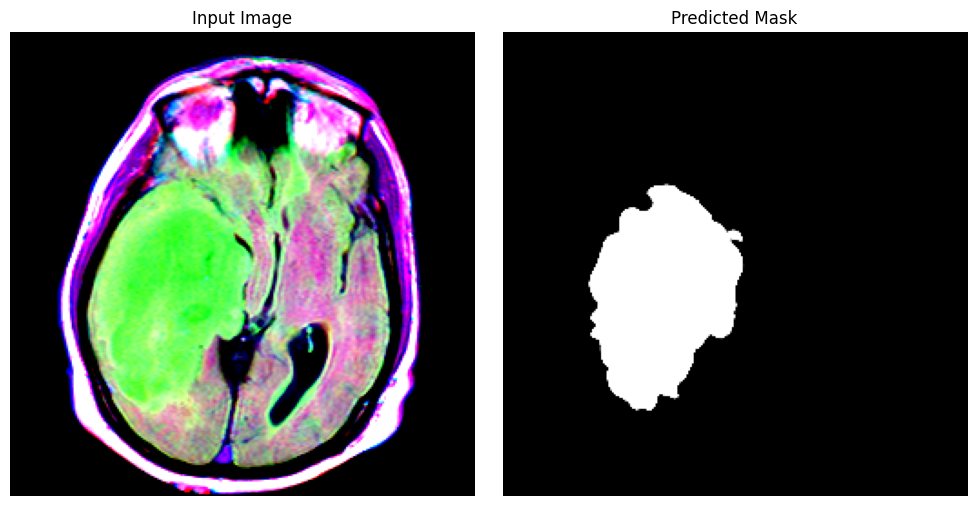

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

img_display = rearrange(image[0], 'c h w -> h w c')
axes[0].imshow(np.array(img_display))
axes[0].set_title("Input Image")
axes[0].axis('off')

axes[1].imshow(np.array(mask[0, 0]), cmap='gray')
axes[1].set_title("Predicted Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()